In [172]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
df = pd.read_csv("../data/preprocessed/supply_chain_disruption.csv")

initial views at the data

In [174]:
df.shape

(31300, 48)

In [175]:
df.head(10)

,date,route_id,route_status,origin_country,destination_country,shipping_method,trade_route_type,distance_km,estimated_transit_days,shipping_delay_days,...,origin_iso3,destination_region,destination_event_region,destination_income_group,destination_port_capacity_index,destination_logistics_performance_index,destination_trade_dependency_score,destination_gdp_per_capita,destination_population,destination_iso3
0,01/04/2015,R1,Delayed,India,United States,Rail,Consumer Goods,8746,19,7.55,...,IND,North America,North America,Low income,21.06,33.87,97.9,63955,250467210,USA
1,01/11/2015,R1,Delayed,India,United States,Rail,Consumer Goods,8746,19,9.33,...,IND,North America,North America,Low income,21.06,33.87,97.9,63955,250467210,USA
2,01/18/2015,R1,Normal,India,United States,Rail,Consumer Goods,8746,19,3.67,...,IND,North America,North America,Low income,21.06,33.87,97.9,63955,250467210,USA
3,01/25/2015,R1,Delayed,India,United States,Rail,Consumer Goods,8746,19,9.22,...,IND,North America,North America,Low income,21.06,33.87,97.9,63955,250467210,USA
4,02/01/2015,R1,Delayed,India,United States,Rail,Consumer Goods,8746,19,6.36,...,IND,North America,North America,Low income,21.06,33.87,97.9,63955,250467210,USA
5,02/08/2015,R1,Delayed,India,United States,Rail,Consumer Goods,8746,19,10.61,...,IND,North America,North America,Low income,21.06,33.87,97.9,63955,250467210,USA
6,02/15/2015,R1,Delayed,India,United States,Rail,Consumer Goods,8746,19,7.56,...,IND,North America,North America,Low income,21.06,33.87,97.9,63955,250467210,USA
7,02/22/2015,R1,Delayed,India,United States,Rail,Consumer Goods,8746,19,8.22,...,IND,North America,North America,Low income,21.06,33.87,97.9,63955,250467210,USA
8,03/01/2015,R1,Delayed,India,United States,Rail,Consumer Goods,8746,19,8.00,...,IND,North America,North America,Low income,21.06,33.87,97.9,63955,250467210,USA
9,03/08/2015,R1,Normal,India,United States,Rail,Consumer Goods,8746,19,3.08,...,IND,North America,North America,Low income,21.06,33.87,97.9,63955,250467210,USA


In [176]:
df.columns

Index(['date', 'route_id', 'route_status', 'origin_country',
       'destination_country', 'shipping_method', 'trade_route_type',
       'distance_km', 'estimated_transit_days', 'shipping_delay_days',
       'port_congestion_index', 'container_availability_index',
       'weather_disruption_score', 'geopolitical_risk_score',
       'trade_volume_tonnes', 'freight_cost_usd', 'carbon_emissions_tonnes',
       'origin_active_event_count', 'origin_active_event_risk',
       'destination_active_event_count', 'destination_active_event_risk',
       'covid_supply_shock_active', 'russia_ukraine_war_active',
       'events_warmup', 'fuel_cost_index', 'commodity_price_index',
       'natural_gas_price', 'steel_price', 'wheat_price', 'copper_price',
       'origin_region', 'origin_event_region', 'origin_income_group',
       'origin_port_capacity_index', 'origin_logistics_performance_index',
       'origin_trade_dependency_score', 'origin_gdp_per_capita',
       'origin_population', 'origin_iso3'

Dropping rows with the Disrupted routed status, as it only accounts for 3% of all total data

In [177]:
# use the inplace=True
# From CA Ashok:
# do a model with and without
# predict disruptions, not on time or not
# and return biggest indicators of such
# distribution center at A, weather disruption at A, asks about A, model says no, weather thing, go to B

# indices_to_drop = df[df['route_status'] == "Disrupted"].index
# df.drop(indices_to_drop, inplace=True)


In [178]:
df.shape

(31300, 48)

In [179]:
df.iloc[30000:] 
# checking that data is ordered chronologically

,date,route_id,route_status,origin_country,destination_country,shipping_method,trade_route_type,distance_km,estimated_transit_days,shipping_delay_days,...,origin_iso3,destination_region,destination_event_region,destination_income_group,destination_port_capacity_index,destination_logistics_performance_index,destination_trade_dependency_score,destination_gdp_per_capita,destination_population,destination_iso3
30000,02/01/2026,R48,Delayed,Brazil,Japan,Rail,Energy,1103,22,5.3600,...,BRA,East Asia & Pacific,Asia,Upper middle income,65.06,34.58,27.25,68969,435285667,JPN
30001,02/08/2026,R48,Delayed,Brazil,Japan,Rail,Energy,1103,22,8.3500,...,BRA,East Asia & Pacific,Asia,Upper middle income,65.06,34.58,27.25,68969,435285667,JPN
30002,02/15/2026,R48,Normal,Brazil,Japan,Rail,Energy,1103,22,0.0000,...,BRA,East Asia & Pacific,Asia,Upper middle income,65.06,34.58,27.25,68969,435285667,JPN
30003,02/22/2026,R48,Normal,Brazil,Japan,Rail,Energy,1103,22,3.6200,...,BRA,East Asia & Pacific,Asia,Upper middle income,65.06,34.58,27.25,68969,435285667,JPN
30004,03/01/2026,R48,Delayed,Brazil,Japan,Rail,Energy,1103,22,8.9200,...,BRA,East Asia & Pacific,Asia,Upper middle income,65.06,34.58,27.25,68969,435285667,JPN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31295,11/29/2026,R50,Delayed,Brazil,United States,Sea,Consumer Goods,8070,28,9.2475,...,BRA,North America,North America,Low income,21.06,33.87,97.90,63955,250467210,USA
31296,12/06/2026,R50,Delayed,Brazil,United States,Sea,Consumer Goods,8070,28,11.7180,...,BRA,North America,North America,Low income,21.06,33.87,97.90,63955,250467210,USA
31297,12/13/2026,R50,Disrupted,Brazil,United States,Sea,Consumer Goods,8070,28,12.6495,...,BRA,North America,North America,Low income,21.06,33.87,97.90,63955,250467210,USA
31298,12/20/2026,R50,Delayed,Brazil,United States,Sea,Consumer Goods,8070,28,11.1240,...,BRA,North America,North America,Low income,21.06,33.87,97.90,63955,250467210,USA


Count number of unique values, will need to one hot encode things

In [180]:
df.nunique()

date                                         626
route_id                                      50
route_status                                   3
origin_country                                10
destination_country                           10
shipping_method                                4
trade_route_type                               5
distance_km                                   50
estimated_transit_days                        31
shipping_delay_days                         2235
port_congestion_index                       9594
container_availability_index                4994
weather_disruption_score                    9585
geopolitical_risk_score                     9559
trade_volume_tonnes                        31145
freight_cost_usd                           30361
carbon_emissions_tonnes                    30928
origin_active_event_count                     93
origin_active_event_risk                    2455
destination_active_event_count                93
destination_active_e

In [181]:
def print_word_count():
        wordy_cols = list(df.select_dtypes(include=["object"]).columns)
        print(wordy_cols)
        for w in wordy_cols:
                print(f"{w}: {df[w].nunique()}")

In [182]:
print_word_count()

['date', 'route_id', 'route_status', 'origin_country', 'destination_country', 'shipping_method', 'trade_route_type', 'origin_region', 'origin_event_region', 'origin_income_group', 'origin_iso3', 'destination_region', 'destination_event_region', 'destination_income_group', 'destination_iso3']
date: 626
route_id: 50
route_status: 3
origin_country: 10
destination_country: 10
shipping_method: 4
trade_route_type: 5
origin_region: 5
origin_event_region: 4
origin_income_group: 4
origin_iso3: 10
destination_region: 5
destination_event_region: 4
destination_income_group: 4
destination_iso3: 10


get rid of: origin iso3, route id, destination iso3, desitnation region (cause its grouped and similar to destination event region)
discussed on call

In [183]:
df.drop(["route_id", "origin_iso3", "destination_iso3", "destination_region"], axis=1, inplace=True)

In [184]:
df.shape

(31300, 44)

In [185]:
df.head(10)

,date,route_status,origin_country,destination_country,shipping_method,trade_route_type,distance_km,estimated_transit_days,shipping_delay_days,port_congestion_index,...,origin_trade_dependency_score,origin_gdp_per_capita,origin_population,destination_event_region,destination_income_group,destination_port_capacity_index,destination_logistics_performance_index,destination_trade_dependency_score,destination_gdp_per_capita,destination_population
0,01/04/2015,Delayed,India,United States,Rail,Consumer Goods,8746,19,7.55,82.22,...,23.73,60735,430389014,North America,Low income,21.06,33.87,97.9,63955,250467210
1,01/11/2015,Delayed,India,United States,Rail,Consumer Goods,8746,19,9.33,72.01,...,23.73,60735,430389014,North America,Low income,21.06,33.87,97.9,63955,250467210
2,01/18/2015,Normal,India,United States,Rail,Consumer Goods,8746,19,3.67,44.64,...,23.73,60735,430389014,North America,Low income,21.06,33.87,97.9,63955,250467210
3,01/25/2015,Delayed,India,United States,Rail,Consumer Goods,8746,19,9.22,97.82,...,23.73,60735,430389014,North America,Low income,21.06,33.87,97.9,63955,250467210
4,02/01/2015,Delayed,India,United States,Rail,Consumer Goods,8746,19,6.36,73.21,...,23.73,60735,430389014,North America,Low income,21.06,33.87,97.9,63955,250467210
5,02/08/2015,Delayed,India,United States,Rail,Consumer Goods,8746,19,10.61,74.91,...,23.73,60735,430389014,North America,Low income,21.06,33.87,97.9,63955,250467210
6,02/15/2015,Delayed,India,United States,Rail,Consumer Goods,8746,19,7.56,80.74,...,23.73,60735,430389014,North America,Low income,21.06,33.87,97.9,63955,250467210
7,02/22/2015,Delayed,India,United States,Rail,Consumer Goods,8746,19,8.22,40.05,...,23.73,60735,430389014,North America,Low income,21.06,33.87,97.9,63955,250467210
8,03/01/2015,Delayed,India,United States,Rail,Consumer Goods,8746,19,8.00,56.59,...,23.73,60735,430389014,North America,Low income,21.06,33.87,97.9,63955,250467210
9,03/08/2015,Normal,India,United States,Rail,Consumer Goods,8746,19,3.08,51.89,...,23.73,60735,430389014,North America,Low income,21.06,33.87,97.9,63955,250467210


In [186]:
print_word_count()

['date', 'route_status', 'origin_country', 'destination_country', 'shipping_method', 'trade_route_type', 'origin_region', 'origin_event_region', 'origin_income_group', 'destination_event_region', 'destination_income_group']
date: 626
route_status: 3
origin_country: 10
destination_country: 10
shipping_method: 4
trade_route_type: 5
origin_region: 5
origin_event_region: 4
origin_income_group: 4
destination_event_region: 4
destination_income_group: 4


Time to one hote encode things now

In [187]:
wordy_cols = list(df.select_dtypes(include=["object"]).columns)
wordy_cols.remove('date')

df_enc = pd.get_dummies(df, columns=wordy_cols,dtype='int')
df_enc.head()

,date,distance_km,estimated_transit_days,shipping_delay_days,port_congestion_index,container_availability_index,weather_disruption_score,geopolitical_risk_score,trade_volume_tonnes,freight_cost_usd,...,origin_income_group_Lower middle income,origin_income_group_Upper middle income,destination_event_region_Asia,destination_event_region_Europe,destination_event_region_North America,destination_event_region_South America,destination_income_group_High income,destination_income_group_Low income,destination_income_group_Lower middle income,destination_income_group_Upper middle income
0,01/04/2015,8746,19,7.55,82.22,71.42,59.51,57.15,8418.69,4586.66,...,0,0,0,0,1,0,0,1,0,0
1,01/11/2015,8746,19,9.33,72.01,79.27,91.27,41.47,9343.00,4574.70,...,0,0,0,0,1,0,0,1,0,0
2,01/18/2015,8746,19,3.67,44.64,60.16,46.69,79.69,7090.69,4520.46,...,0,0,0,0,1,0,0,1,0,0
3,01/25/2015,8746,19,9.22,97.82,66.43,56.39,67.15,7829.79,4696.95,...,0,0,0,0,1,0,0,1,0,0
4,02/01/2015,8746,19,6.36,73.21,96.20,95.92,7.59,11339.59,4507.98,...,0,0,0,0,1,0,0,1,0,0


In [188]:
df_enc.columns

Index(['date', 'distance_km', 'estimated_transit_days', 'shipping_delay_days',
       'port_congestion_index', 'container_availability_index',
       'weather_disruption_score', 'geopolitical_risk_score',
       'trade_volume_tonnes', 'freight_cost_usd', 'carbon_emissions_tonnes',
       'origin_active_event_count', 'origin_active_event_risk',
       'destination_active_event_count', 'destination_active_event_risk',
       'covid_supply_shock_active', 'russia_ukraine_war_active',
       'events_warmup', 'fuel_cost_index', 'commodity_price_index',
       'natural_gas_price', 'steel_price', 'wheat_price', 'copper_price',
       'origin_port_capacity_index', 'origin_logistics_performance_index',
       'origin_trade_dependency_score', 'origin_gdp_per_capita',
       'origin_population', 'destination_port_capacity_index',
       'destination_logistics_performance_index',
       'destination_trade_dependency_score', 'destination_gdp_per_capita',
       'destination_population', 'route_statu

In [189]:
# df[df_enc["origin_country_United Kingdom"] == 1].count()
# random test 

Before doing correlation, need to standardize data

In [190]:
df_enc.describe()

,distance_km,estimated_transit_days,shipping_delay_days,port_congestion_index,container_availability_index,weather_disruption_score,geopolitical_risk_score,trade_volume_tonnes,freight_cost_usd,carbon_emissions_tonnes,...,origin_income_group_Lower middle income,origin_income_group_Upper middle income,destination_event_region_Asia,destination_event_region_Europe,destination_event_region_North America,destination_event_region_South America,destination_income_group_High income,destination_income_group_Low income,destination_income_group_Lower middle income,destination_income_group_Upper middle income
count,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,...,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000
mean,7333.600000,25.120000,6.381002,49.697852,75.050266,50.560283,50.957961,18823.910606,4058.009023,6454.535299,...,0.100000,0.340000,0.420000,0.260000,0.280000,0.040000,0.120000,0.300000,0.080000,0.500000
std,3826.216702,12.143735,2.963550,28.812003,14.448535,28.791971,29.086102,9693.552809,1611.577578,4699.908491,...,0.300005,0.473716,0.493566,0.438641,0.449006,0.195962,0.324967,0.458265,0.271298,0.500008
min,564.000000,3.000000,0.000000,0.000000,50.010000,0.000000,0.000000,2372.895000,685.430000,213.030000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4901.000000,16.000000,4.330000,24.780000,62.540000,25.747500,25.950000,11609.895000,2950.445000,2983.857500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7652.500000,26.500000,6.320000,49.380000,75.180000,50.855000,50.970000,17108.200000,4215.945000,5718.980000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000
75%,10335.000000,36.000000,8.380000,74.802500,87.690000,75.500000,76.232500,24730.025000,5217.350000,8857.477500,...,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,14048.000000,45.000000,20.952000,100.000000,100.000000,99.990000,100.000000,49380.230000,9659.594000,33095.970000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


DO CORRELATION!!! (but first one hot encode route_status and others)
note: correlation matrix doesn't work with any columns containing object values (aka strings) cause date column is still there, will use numeric_only parameter.

In [191]:
correlations = df_enc.corr(numeric_only=True)
correlations

,distance_km,estimated_transit_days,shipping_delay_days,port_congestion_index,container_availability_index,weather_disruption_score,geopolitical_risk_score,trade_volume_tonnes,freight_cost_usd,carbon_emissions_tonnes,...,origin_income_group_Lower middle income,origin_income_group_Upper middle income,destination_event_region_Asia,destination_event_region_Europe,destination_event_region_North America,destination_event_region_South America,destination_income_group_High income,destination_income_group_Low income,destination_income_group_Lower middle income,destination_income_group_Upper middle income
distance_km,1.000000,0.051303,0.005389,-0.000793,-0.001525,0.002243,0.001002,-0.258182,0.968087,0.548260,...,0.103394,-0.278328,-0.348528,0.161727,0.215568,0.021895,-0.002229,0.255828,-0.260545,-0.091653
estimated_transit_days,0.051303,1.000000,0.003598,0.000877,-0.001028,0.002405,0.001381,-0.069292,0.049787,0.008274,...,-0.107602,0.083303,-0.055126,0.005407,-0.057516,0.258527,0.219351,-0.049597,0.069936,-0.135051
shipping_delay_days,0.005389,0.003598,1.000000,0.384723,-0.488756,0.342635,0.506427,-0.193133,0.074290,-0.126522,...,0.003823,0.000054,-0.001586,0.004004,-0.002379,0.000485,0.003544,-0.004478,-0.005421,0.004743
port_congestion_index,-0.000793,0.000877,0.384723,1.000000,0.007873,0.000039,-0.008854,0.004022,0.013303,0.003649,...,0.001836,0.007172,-0.002463,0.001338,0.002058,-0.001508,0.003989,-0.004531,0.001239,0.000888
container_availability_index,-0.001525,-0.001028,-0.488756,0.007873,1.000000,-0.000482,-0.985651,0.364298,-0.018034,0.253039,...,-0.001135,-0.007376,0.007230,-0.002956,-0.001520,-0.008111,0.002410,0.005467,0.006531,-0.010121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
destination_event_region_South America,0.021895,0.258527,0.000485,-0.001508,-0.008111,-0.007383,0.008437,0.149446,0.021209,0.174751,...,-0.068041,0.284398,-0.173702,-0.120994,-0.127294,1.000000,0.552771,-0.133631,-0.060193,-0.204124
destination_income_group_High income,-0.002229,0.219351,0.003544,0.003989,0.002410,-0.004362,-0.002131,0.014246,-0.002027,0.088039,...,-0.123091,0.384573,0.184553,-0.218887,-0.230283,0.552771,1.000000,-0.241747,-0.108893,-0.369274
destination_income_group_Low income,0.255828,-0.049597,-0.004478,-0.004531,0.005467,0.004859,-0.005721,-0.099567,0.247450,0.114238,...,-0.218218,-0.193476,-0.557086,0.606943,0.077762,-0.133631,-0.241747,1.000000,-0.193047,-0.654654
destination_income_group_Lower middle income,-0.260545,0.069936,-0.005421,0.001239,0.006531,-0.003646,-0.006281,-0.135073,-0.252383,-0.221262,...,-0.098295,0.099600,0.346530,-0.174792,-0.183892,-0.060193,-0.108893,-0.193047,1.000000,-0.294884


For route_status_Delayed column

In [192]:
correlations["route_status_Delayed"].sort_values(ascending=False).head(51)

route_status_Delayed                            1.000000
shipping_delay_days                             0.595050
geopolitical_risk_score                         0.321238
port_congestion_index                           0.246012
weather_disruption_score                        0.223041
freight_cost_usd                                0.017425
origin_event_region_South America               0.014467
origin_country_Brazil                           0.014467
origin_region_Latin America & Caribbean         0.014467
destination_population                          0.013590
destination_country_Germany                     0.012815
origin_income_group_High income                 0.010268
shipping_method_Rail                            0.008825
destination_country_United Kingdom              0.008611
origin_port_capacity_index                      0.007833
origin_logistics_performance_index              0.007054
destination_country_India                       0.006615
trade_route_type_Agriculture   

looking at correlation right now, only 49 columns out of all 86 have a positive correlation with the route_status_delayed column. and of those 49, only around 5 have a useful correlation with this column. 

For route_status_Normal column

In [193]:
correlations["route_status_Normal"].sort_values(ascending=False).head(45)

route_status_Normal                             1.000000
container_availability_index                    0.394281
trade_volume_tonnes                             0.152096
carbon_emissions_tonnes                         0.106111
origin_income_group_Low income                  0.012477
origin_country_United Kingdom                   0.010537
russia_ukraine_war_active                       0.009840
origin_region_Europe & Central Asia             0.008435
origin_event_region_Europe                      0.008435
destination_trade_dependency_score              0.008098
shipping_method_Road                            0.007180
shipping_method_Air                             0.006954
origin_country_United States                    0.005990
origin_gdp_per_capita                           0.004884
covid_supply_shock_active                       0.004794
trade_route_type_Energy                         0.004744
origin_active_event_risk                        0.004703
destination_country_Australia  

looking at correlation right now, only 43 columns out of all 86 have a positive correlation with the route_status_Normal column. and of those 43, only around 5 have a useful correlation with this column.

For route_status_Disrupted column

In [194]:
correlations["route_status_Disrupted"].sort_values(ascending=False).head(40)

route_status_Disrupted                          1.000000
shipping_delay_days                             0.423226
geopolitical_risk_score                         0.193186
port_congestion_index                           0.140307
weather_disruption_score                        0.127822
freight_cost_usd                                0.062323
natural_gas_price                               0.031924
shipping_method_Road                            0.015184
origin_active_event_count                       0.012569
origin_active_event_risk                        0.010755
destination_country_Canada                      0.010583
origin_region_South Asia                        0.009580
origin_country_India                            0.009580
destination_country_Australia                   0.008821
destination_income_group_Lower middle income    0.008821
destination_country_France                      0.008532
destination_active_event_risk                   0.007784
destination_trade_dependency_sc

looking at correlation right now, only 38 columns out of all 86 have a positive correlation with the route_status_Normal column. and of those 38, only around 5 have a useful correlation with this column.

Important note, this is before any data has been standardized. It doesn't make sense to standardize all of the them as we may not use all of the columns. However, We will discuss and then later standardize columns we will 100% use.

Another note, these columns seem to have the highest correlations with the labels: 
<br>
shipping_delay_days 
<br>
geopolitical_risk_score
<br>
port_congestion_index
<br>
weather_disruption_score
<br>
container_availability_index
<br>
trade_volume_tonnes
<br>

Also it seems obvious that delayed and disrupted had very similar correlations with other columns

Describing chosen columns

In [195]:
df_enc[["shipping_delay_days", "geopolitical_risk_score", "port_congestion_index", "weather_disruption_score", "container_availability_index", "trade_volume_tonnes"]].describe()

,shipping_delay_days,geopolitical_risk_score,port_congestion_index,weather_disruption_score,container_availability_index,trade_volume_tonnes
count,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000,31300.000000
mean,6.381002,50.957961,49.697852,50.560283,75.050266,18823.910606
std,2.963550,29.086102,28.812003,28.791971,14.448535,9693.552809
min,0.000000,0.000000,0.000000,0.000000,50.010000,2372.895000
25%,4.330000,25.950000,24.780000,25.747500,62.540000,11609.895000
50%,6.320000,50.970000,49.380000,50.855000,75.180000,17108.200000
75%,8.380000,76.232500,74.802500,75.500000,87.690000,24730.025000
max,20.952000,100.000000,100.000000,99.990000,100.000000,49380.230000


Definetly need to np.log() container and trade_volume columns

visuals for chosen columns

<Axes: xlabel='shipping_delay_days'>

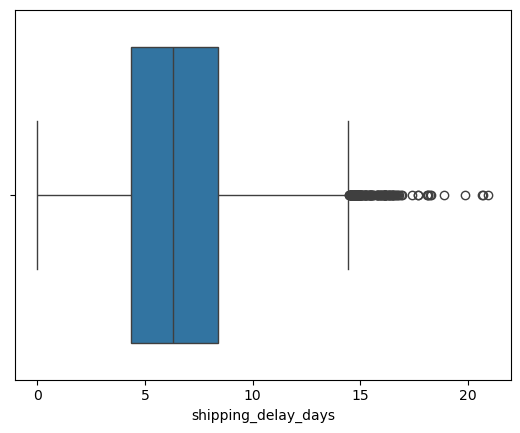

In [196]:
fig1, ax1 = plt.subplots()
sns.boxplot(x=df_enc['shipping_delay_days'])

<Axes: xlabel='geopolitical_risk_score'>

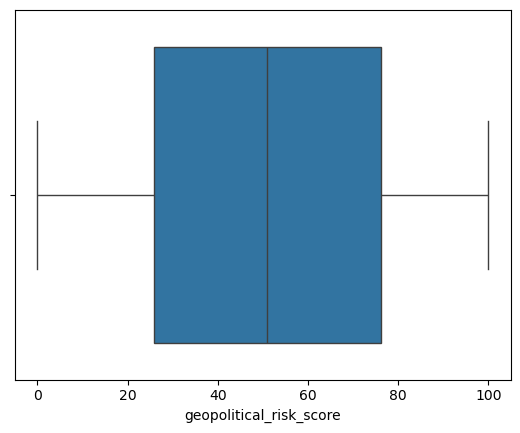

In [197]:
sns.boxplot(x=df_enc['geopolitical_risk_score'])

<Axes: xlabel='port_congestion_index'>

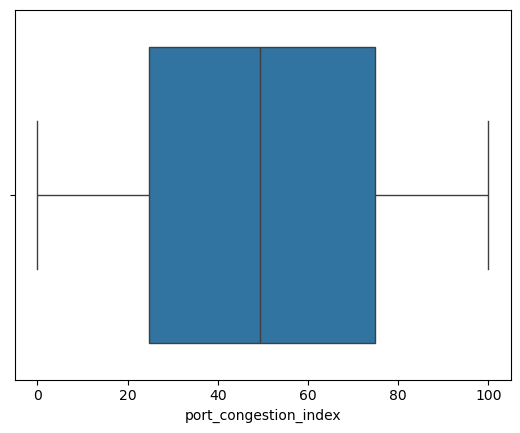

In [198]:
sns.boxplot(x=df_enc['port_congestion_index'])

<Axes: xlabel='weather_disruption_score'>

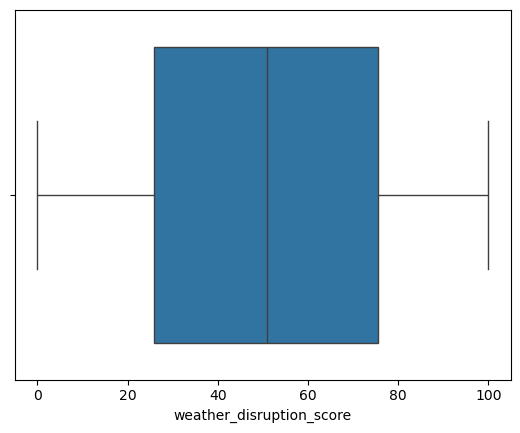

In [199]:
sns.boxplot(x=df_enc['weather_disruption_score'])

<Axes: xlabel='container_availability_index'>

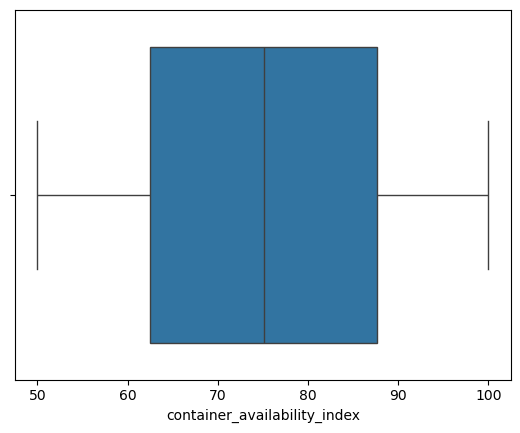

In [200]:
sns.boxplot(x=df_enc['container_availability_index'])

<Axes: xlabel='trade_volume_tonnes'>

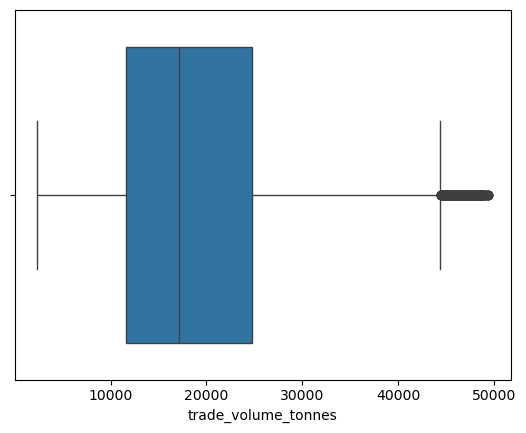

In [201]:
sns.boxplot(x=df_enc['trade_volume_tonnes'])

note todo, after cleaning, separate data into train and text based on dates.